In [ ]:
#Quest3 superfinal:

import numpy as np
import matplotlib.pyplot as plt
import math

#parameters             #[unit] 
total_time  = 500       #[ms]        -  total time
tau_m = 20              #[ms]        -  membrane time constant - how quick voltage decays in membrane (when no input)
delta_v = 0             #[mV]        -  delta of voltage
delta_t = 0.1           #[ms]        -  delta of time
El = -70                #[mV]        -  reversal potential - resting membrane potential
v = []                  #[mV]        -  voltage inside neuron at given time t
R_m = 10                #[MegaOhms]  -  membrane resistance --> THRESHOLD
I_e = np.array([2,2,2])                 #[nA]        -  current input from electrode/neighboring neurons - if const --> ODE
v_threshold = -55       #[mV]        -  threshold voltage to spike
v_reset = -70           #[mV]        -  reset voltage after spike
ref_period = 0

#initialize I_e if it's None, or make sure it's defined before this block
#I_e = np.zeros(len(inhib_rand)) if I_e is None else I_e

# initialize arrays
num_steps = int(total_time / delta_t) # how many time steps
#sim_time = np.arange(0, total_time, delta_t)  # continuous simulation time array
#v = np.ones(num_steps) * El  # membrane potential initialized to resting potential
spike_times = []  # spike times array
#spike_train = np.zeros(num_steps)  # spike train array to store spikes (0 = no spike, 1 = spike)
stimulus = np.loadtxt('stim.dat') 
#stimulus = np.zeros(num_steps)


In [ ]:
#LIF neuron simulation:

def lif_sim(I_e, spike_train=None):
    """
    Simulate the behavior of a Leaky Integrate-and-Fire (LIF) neuron.
    """
    
    delta_t = 0.1
    tau_m = 20
    El = -70
    R_m = 10
    v_threshold = -55
    v_reset = -70
    ref_period = 0
    
    #check for stimulus:
    if stimulus is not None:
        i_e = np.resize(I_e, len(stimulus))
    else:
        i_e = np.zeros_like(i_e)  #keep I_e as it was, or default to its original definition

    #adjust to I_e:
    num_steps = int(max(len(I_e) * delta_t, 500) // delta_t)
    sim_time = np.arange(0, num_steps * delta_t, delta_t)  #simulation time steps
    v = np.ones(num_steps) *El

    spike_train = np.zeros(num_steps) if spike_train is None else spike_train
    spike_times = []  #initialize spike tracking
    isSpiking = False

    #print("lifsim I_e input:", I_e, "of length", len(I_e))

    for t in range(1, num_steps):
        if isSpiking:
            v[t], isSpiking = v_reset, False
        else:
            current_I_e = I_e[min(t, len(I_e)-1)]  #current input at time step t
            if isinstance(current_I_e, (np.ndarray, list)):  # Check if sequence
                current_I_e = current_I_e[0]
            
            delta_v = ((El - v[t-1]) + (R_m * current_I_e)) / tau_m  #lif
            v[t] = v[t-1] + delta_v * delta_t  #update membrane potential

            if v[t] >= v_threshold and v[t-1] < v_threshold:  #spike detection
                spike_times.append(sim_time[t])  #record spike time
                spike_train[t] = 1  #mark spike
                v[t], isSpiking = 40, True  #reset after spike

    return v, sim_time, spike_times, spike_train


Length of I_e post LIF: [2 2 2] 3
Length of v: 4999
Length of sim_time: 4999


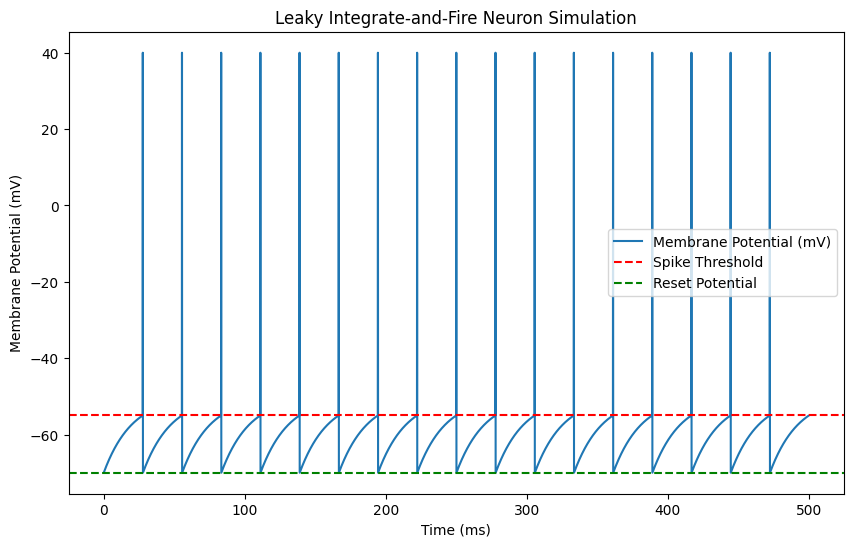

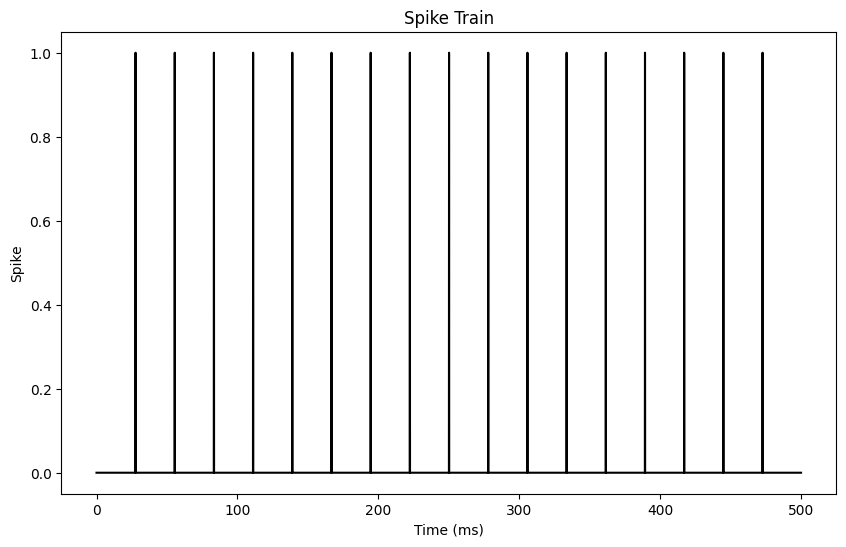

In [ ]:
#run and plot lif neuron for I_e of:

#run lif simulation
v, sim_time, spike_times, spike_train = lif_sim(I_e=I_e)

#debug print
print("Length of I_e post LIF:", I_e, len(I_e))
print("Length of v:", len(v))
print("Length of sim_time:", len(sim_time))

#plot membrane potential over time
plt.figure(figsize=(10, 6))
plt.plot(sim_time, v, label="Membrane Potential (mV)")  #ensure v has values
plt.axhline(y=v_threshold, color='r', linestyle='--', label="Spike Threshold")
plt.axhline(y=v_reset, color='g', linestyle='--', label="Reset Potential")
plt.title("Leaky Integrate-and-Fire Neuron Simulation")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.show()

#plot spike train
plt.figure(figsize=(10, 6))
plt.plot(sim_time, spike_train, label="Spike Train", color="black")
plt.title("Spike Train")
plt.xlabel("Time (ms)")
plt.ylabel("Spike")
plt.show()


In [ ]:
#Poisson noise generator:

def generate_poisson_weights(I_e, weak_percent):

    #fixed lambda ranges
    weak_lambda_range=(0, 5)
    strong_lambda_range=(50, 100)

    weak_percent = weak_percent/100 #allowing for there to be a percentage input

    #ensure weak_ratio is valid
    if not (0 < weak_percent < 1):
        raise ValueError("weak_ratio must be between 0 and 1.")
    
    #print input I_e
    #print("input I_e", I_e, "of type", type(I_e))
    
    if isinstance(I_e, (list, np.ndarray)):  #check if I_e list or numpy array
        if len(I_e) <= 1:
            I_e = np.ones(len(I_e))  #array of ones of len(I_e)
        else:
            I_e = I_e  #no change if length is greater than 1
    elif isinstance(I_e, (int, float)):  #check if I_e scalar(int or float)
            I_e = np.ones([I_e])  #convert to a 1-element array

    if stimulus is not None:
        I_e = np.resize(I_e, len(stimulus)) 

    num_steps = (len(I_e))
    #print("num_steps", num_steps)
    n_weak = int(num_steps * weak_percent)
    n_strong = num_steps - n_weak  #remaining are strong events
    print("number of strong lams:", n_strong)
    
    print("number of weak lams:", n_weak)
    
    #generate weak and strong lambdas
    weak_lambdas = np.random.uniform(*weak_lambda_range, n_weak)
    strong_lambdas = np.random.uniform(*strong_lambda_range, n_strong)
    
    #merge lambdas
    lambdas = np.concatenate((weak_lambdas, strong_lambdas))
    print("unshuffled lambdas", lambdas)
    #shuffle the lambdas to randomize weak and strong order
    np.random.shuffle(lambdas)
    print("shuffled lambdas", lambdas)
    #generate random inhibitory and excitatory weights
    inhib_rand = -1 * np.random.poisson(lambdas)  #negative inhibitory
    excit_rand = np.random.poisson(lambdas)      #positive excitatory
    print("inhib_rand", inhib_rand, "of type", type(inhib_rand))
    print("excit_rand", excit_rand, "of type", type(excit_rand))
    #np.random.shuffle(inhib_rand)
    #np.random.shuffle(excit_rand)
    I_e_rand_injected = (I_e + inhib_rand + excit_rand) * 10
    #print("output I_e_rand_injected", I_e_rand_injected, "of type", type(I_e_rand_injected), "of len", len(I_e_rand_injected))
    #print output I_e
    #print("output I_e", I_e, "of type", type(I_e), "of len", len(I_e))

    #predefined set combinations for weak and strong lambdas
    inhib_weak = (-1 * np.random.poisson(weak_lambdas))
    inhib_strong = (-1 * np.random.poisson(strong_lambdas))
    excit_weak = np.random.poisson(weak_lambdas)
    excit_strong = np.random.poisson(strong_lambdas)

    #define combinations
    combinations = {
        "Inhibitory Weak-Strong, Excitatory Weak-Strong": (np.concatenate((inhib_weak, inhib_strong)), np.concatenate((excit_weak, excit_strong))),
        "Inhibitory Strong-Weak, Excitatory Weak-Strong": (np.concatenate((inhib_strong, inhib_weak)), np.concatenate((excit_weak, excit_strong))),
        "Inhibitory Weak-Strong, Excitatory Strong-Weak": (np.concatenate((inhib_weak, inhib_strong)), np.concatenate((excit_strong, excit_weak))),
        "Inhibitory Strong-Weak, Excitatory Strong-Weak": (np.concatenate((inhib_strong, inhib_weak)), np.concatenate((excit_strong, excit_weak))),
        
    }

    return inhib_rand, excit_rand, combinations, I_e_rand_injected

In [131]:
#Run fixed values (combinations):

inhib_rand, excit_rand, combinations, I_e = generate_poisson_weights(num_steps, weak_percent=80) #Weak Ratio(%)



number of strong lams: 1000
number of weak lams: 4000
unshuffled lambdas [ 3.56034048  3.23698533  1.45619853 ... 89.95470974 65.8574775
 95.98773663]
shuffled lambdas [62.52795664  3.27367064 55.14031277 ...  4.59488536  1.24608754
  2.93325974]
inhib_rand [-61  -5 -63 ...  -5  -1   0] of type <class 'numpy.ndarray'>
excit_rand [56  3 46 ...  6  1  3] of type <class 'numpy.ndarray'>


number of strong lams: 2000
number of weak lams: 3000
unshuffled lambdas [ 0.65965964  2.7529185   1.95637419 ... 95.02559638 99.83411568
 72.50090928]
shuffled lambdas [9.30923422e-01 7.43617197e-02 2.87421743e+00 ... 4.04504908e+00
 8.18121348e+01 9.47515791e-01]
inhib_rand [ -1  -1  -3 ...  -4 -70  -1] of type <class 'numpy.ndarray'>
excit_rand [ 5  1  2 ...  2 88  0] of type <class 'numpy.ndarray'>
number of strong lams: 1500
number of weak lams: 3500
unshuffled lambdas [ 3.41190621  1.17703088  1.80557318 ... 99.59799997 85.19233257
 55.97655411]
shuffled lambdas [ 2.18992221  0.06229514  4.66472544 ... 52.60913028  1.67085285
  4.99802475]
inhib_rand [ -1   0  -4 ... -51   0  -5] of type <class 'numpy.ndarray'>
excit_rand [ 2  0  4 ... 47  4  1] of type <class 'numpy.ndarray'>
number of strong lams: 1000
number of weak lams: 4000
unshuffled lambdas [ 0.70852894  3.27324887  3.07933139 ... 88.04645872 53.64677264
 58.12580484]
shuffled lambdas [2.72722376 4.14464049 3.08537097 ...

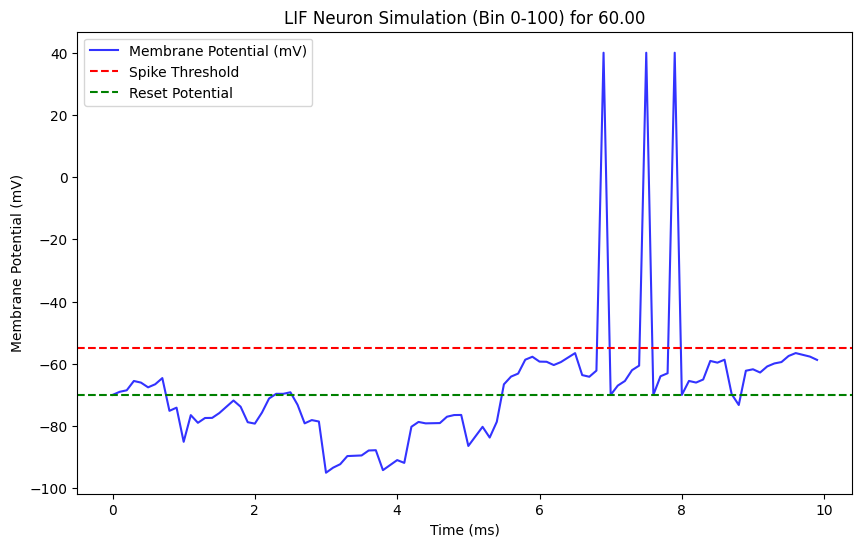

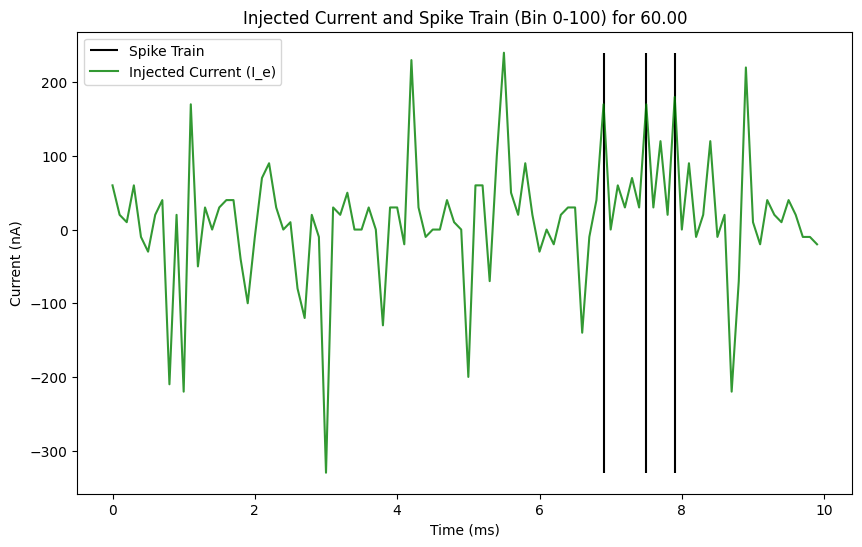

Injected value: [ 30.  20.  20. ... -20.  60. -20.]
Stimulus: [0. 0. 0. ... 0. 0. 0.]
I_e injected final (after summing injected value and stimulus): [ 30.  20.  20. ... -20.  60. -20.]
Injected I_e passed to lif_sim: [ 30.  20.  20. ... -20.  60. -20.]
CV for 70.00: 0.7941794583596306
Fano factor for 70.00: 0.7427184466019418


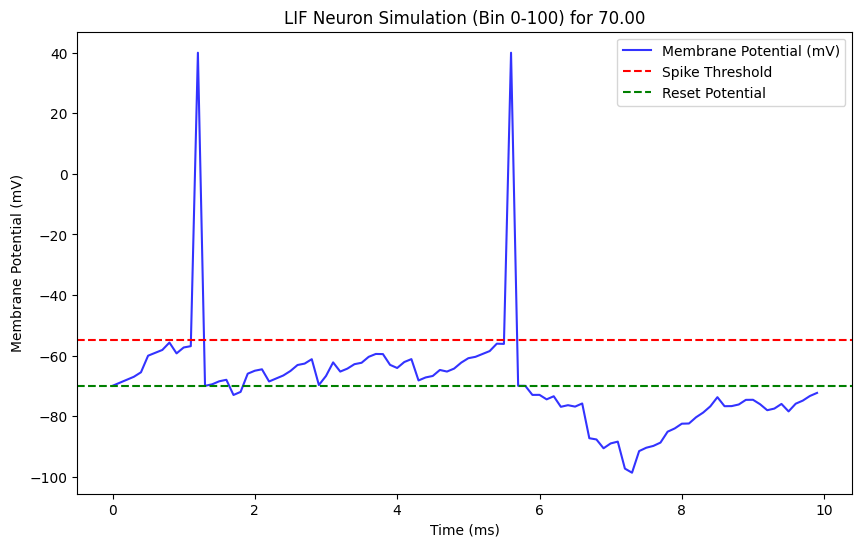

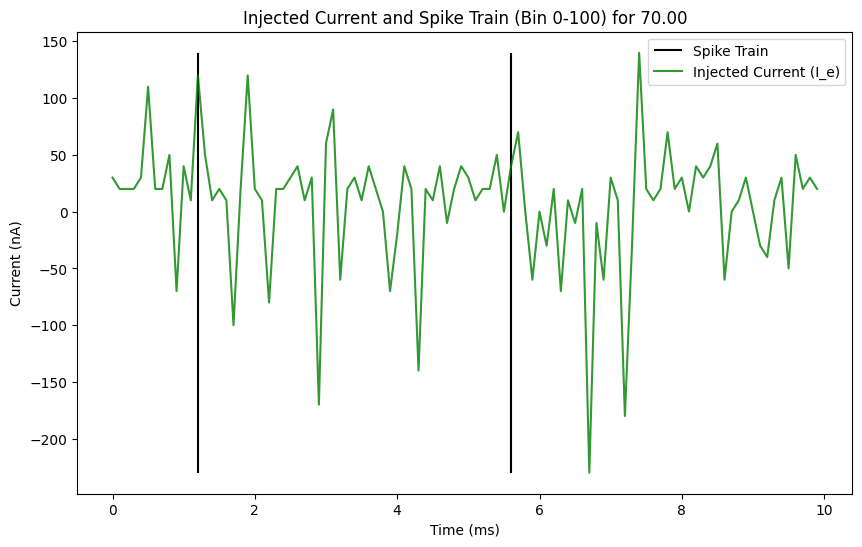

Injected value: [ 20.  50. -10. ...  30.  50.   0.]
Stimulus: [0. 0. 0. ... 0. 0. 0.]
I_e injected final (after summing injected value and stimulus): [ 20.  50. -10. ...  30.  50.   0.]
Injected I_e passed to lif_sim: [ 20.  50. -10. ...  30.  50.   0.]
CV for 80.00: 0.6515769919100461
Fano factor for 80.00: 0.39055299539170507


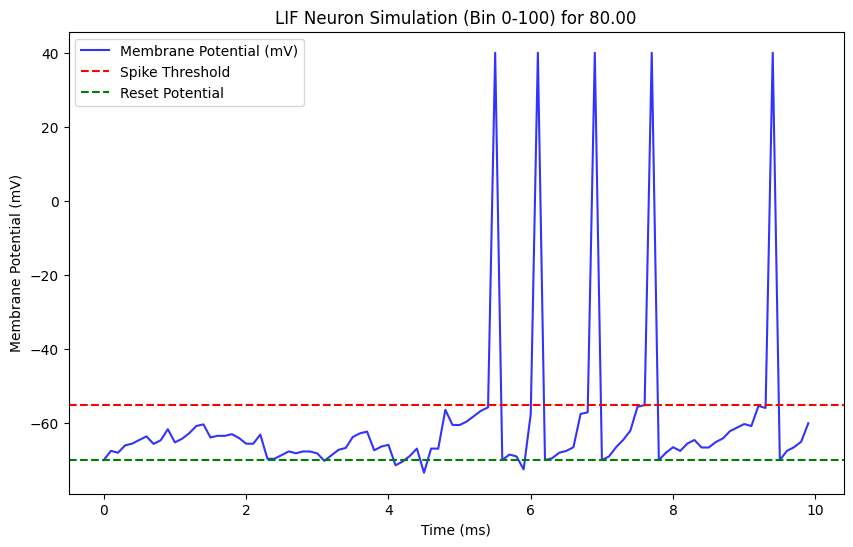

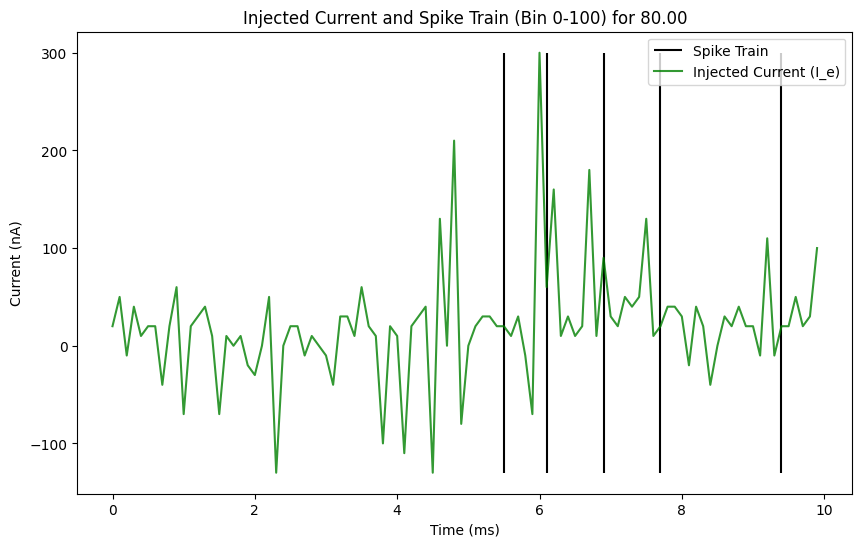

Injected value: [ 50.  40.   0. ...  40.   0. -10.]
Stimulus: [0. 0. 0. ... 0. 0. 0.]
I_e injected final (after summing injected value and stimulus): [ 50.  40.   0. ...  40.   0. -10.]
Injected I_e passed to lif_sim: [ 50.  40.   0. ...  40.   0. -10.]
CV for 90.00: 0.5430177316896236
Fano factor for 90.00: 0.3055555555555556


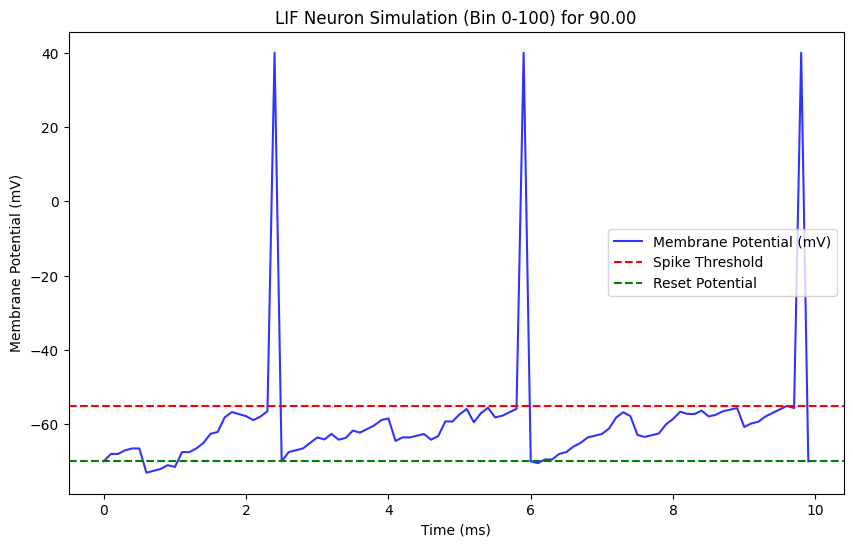

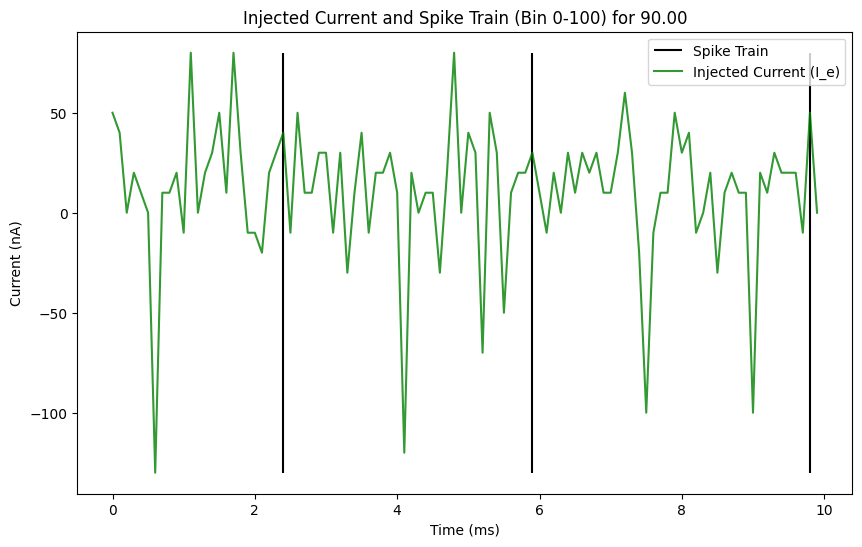

In [132]:
#Randomized noise generation:

#dictionary for results: 
weak_lam_percents = {}

#define weak lambda percentages
weak_lam_percent = [60, 70, 80, 90]

#check and initialize stimulus if necessary
if stimulus is None or len(stimulus) == 0:
    stimulus = np.zeros(len(inhib_rand))
#print("stimulus", stimulus, "of size", len(stimulus))

#ensure I_e is the same len as stimulus:
I_e = np.ones(len(stimulus)) * 2 #setting it to an array of 2s the length of inhib_rand.
#print("I_e", I_e, "of size", len(I_e))

#loop through each rate and call the function, storing the outputs
for percent in weak_lam_percent:
    #print(percent)
    inhib_rand, excit_rand, combinations, I_e_rand_injected = generate_poisson_weights(I_e, percent) #weak Ratio(%)
    weak_lam_percents[f"{percent:.2f}"] = ([inhib_rand], [excit_rand], [I_e_rand_injected])  #store outputs as separate lists
    #the third element in the tuple
    #I_e_rand_injected = [i + s for i, s in zip(I_e_rand_injected, stimulus)]
    #check if stimulus has the same length as I_e_rand_injected

results = {} #array for LIF results for different rates.
bin_size = 100 #size of each bin
cv_list = []
fano_list = []
max_cv = -np.inf
max_fano = -np.inf
cv_max = {}
fano_max = {}

for percent in weak_lam_percents:
    #extract the injected I_e value and modify it with the stimulus
    injected_value = weak_lam_percents[percent][2][0]  #accessing the third element
    print("Injected value:", injected_value)
    print("Stimulus:", stimulus)

    #calculate the final I_e by adding the injected_value and stimulus and dividing by 10
    I_e = (injected_value + stimulus)
    print("I_e injected final (after summing injected value and stimulus):", I_e)

    #run the function and store the result
    v, sim_time, spike_times, spike_train = lif_sim(I_e)
    print(f"Injected I_e passed to lif_sim: {I_e}")
    
    #calc cv
    if len(spike_times) > 1:
        isis = np.diff(spike_times) #isi
        cv = np.std(isis) / np.mean(isis) #cv
        cv_list.append(cv)
        print(f"CV for {percent}: {cv}")

        #update max CV and corresponding details
        if cv > max_cv:
            max_cv = cv
            cv_max_details = {
                'percent': percent,
                'inhib': weak_lam_percents[percent][0][0],  #inhibitory value
                'excit': weak_lam_percents[percent][1][0]   #excitatory value
            }

    #calculate and print the fano
    if len(spike_times) > 1:
        #calculate spike counts in 100 ms bins
        bin_counts, _ = np.histogram(spike_times, bins=np.arange(0, sim_time[-1], 100))
        mean_count = np.mean(bin_counts)
        var_count = np.var(bin_counts)
        fano = var_count / mean_count if mean_count > 0 else 0
        fano_list.append(fano)
        print(f"Fano factor for {percent}: {fano}")
        
        if fano > max_fano:
            max_fano = fano
            fano_max_details = {
                'percent': percent,
                'inhib': weak_lam_percents[percent][0][0],  #inhibitory value
                'excit': weak_lam_percents[percent][1][0]   #excitatory value
            }


    #select a specific bin to zoom in
    bin_start = 0  #starting index of the bin
    bin_end = bin_start + bin_size  #ending index of the bin

    #ensure the bin range doesn't exceed the array length
    bin_end = min(bin_end, len(sim_time))

    #slice data for the selected bin
    binned_time = sim_time[bin_start:bin_end]
    binned_v = v[bin_start:bin_end]
    binned_I_e = I_e[bin_start:bin_end] if hasattr(I_e, '__getitem__') else I_e

    #filter spikes within this bin
    binned_spike_times = np.array(spike_times)
    binned_spike_times = binned_spike_times[
        (binned_spike_times >= binned_time[0]) & (binned_spike_times <= binned_time[-1])]
    
    #plot membrane potential for the bin
    plt.figure(figsize=(10, 6))
    plt.plot(binned_time, binned_v, color='blue', label="Membrane Potential (mV)", alpha=0.8)
    plt.axhline(y=v_threshold, color='r', linestyle='--', label="Spike Threshold")
    plt.axhline(y=v_reset, color='g', linestyle='--', label="Reset Potential")
    plt.title(f"LIF Neuron Simulation (Bin {bin_start}-{bin_end}) for {percent}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Potential (mV)")
    plt.legend()
    plt.show()

    #plot spike train and current for the bin
    plt.figure(figsize=(10, 6))
    plt.vlines(binned_spike_times, ymin=np.min(binned_I_e), ymax=np.max(binned_I_e), color='black', label="Spike Train")
    plt.plot(binned_time, binned_I_e, label="Injected Current (I_e)", color='green', alpha=0.8)
    plt.title(f"Injected Current and Spike Train (Bin {bin_start}-{bin_end}) for {percent}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Current (nA)")
    plt.legend()
    plt.show()


    

Max CV: 0.8098524141779685 found at 60.00% with inhibitory [ -1  -1  -3 ...  -4 -70  -1] and excitatory [ 5  1  2 ...  2 88  0]
Max Fano factor: 0.7427184466019418 found at 70.00% with inhibitory [ -1   0  -4 ... -51   0  -5] and excitatory [ 2  0  4 ... 47  4  1]
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>


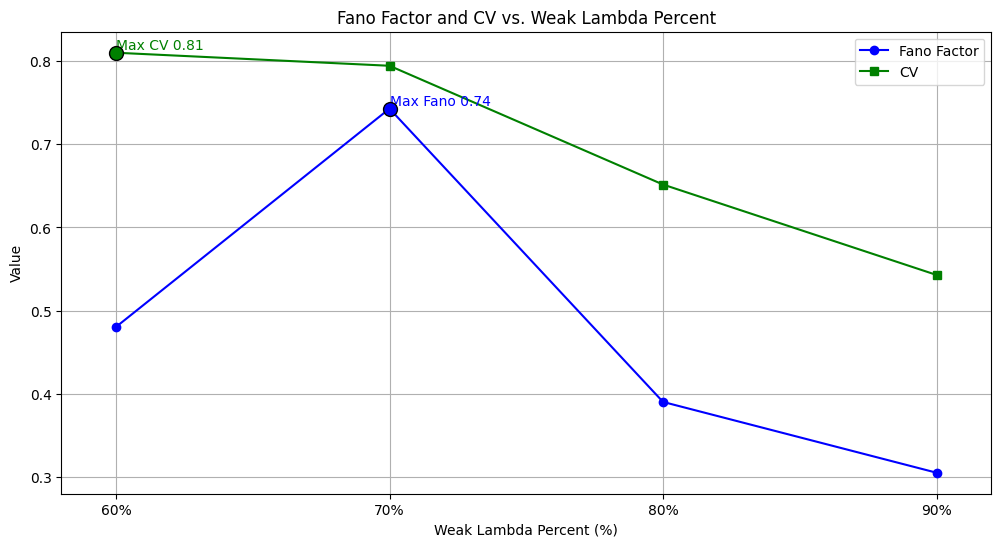

In [133]:
#print maximum CV and Fano factor and their corresponding details
print(f"Max CV: {max_cv} found at {cv_max_details['percent']}% with inhibitory {cv_max_details['inhib']} and excitatory {cv_max_details['excit']}")
print(f"Max Fano factor: {max_fano} found at {fano_max_details['percent']}% with inhibitory {fano_max_details['inhib']} and excitatory {fano_max_details['excit']}")
#find index in weak_lam_percent where max Fano or CV occurs

#fano_max_idx = int(float(fano_max_details['percent']))
#cv_max_idx = int(float(cv_max_details['percent']))
fano_max_value = (max_fano)
cv_max_value = (max_cv)

#print(type(fano_max_idx))
#print(type(cv_max_idx))
print(type(fano_max_value))
print(type(cv_max_value))
print(type(fano_max_value))
#print(type({cv_max_details['inhib']}))

#plotting curves
plt.figure(figsize=(12, 6))
plt.plot(weak_lam_percent, fano_list, label="Fano Factor", color='blue', marker='o')
plt.plot(weak_lam_percent, cv_list, label="CV", color='green', marker='s')

#mark maximum points on the curves
#find max value and its index for Fano Factor
fano_max_idx = fano_list.index(max(fano_list))
plt.scatter(weak_lam_percent[fano_max_idx], max(fano_list), color='blue', s=100, edgecolor='black', zorder=5)
plt.text(weak_lam_percent[fano_max_idx], max(fano_list), f'Max Fano {max(fano_list):.2f}', color='blue', ha='left', va='bottom')

#find max value and its index for CV
cv_max_idx = cv_list.index(max(cv_list))
plt.scatter(weak_lam_percent[cv_max_idx], max(cv_list), color='green', s=100, edgecolor='black', zorder=5)
plt.text(weak_lam_percent[cv_max_idx], max(cv_list), f'Max CV {max(cv_list):.2f}', color='green', ha='left', va='bottom')

#set x-axis limits + labels
plt.xlim(left=min(weak_lam_percent) - 2, right=max(weak_lam_percent) + 2)
step = max(1, len(weak_lam_percent) // 10)  #adjust step size for tick spacing
plt.xticks(weak_lam_percent[::step], [f"{int(x)}%" for x in weak_lam_percent[::step]])

#title + labels
plt.title("Fano Factor and CV vs. Weak Lambda Percent")
plt.xlabel("Weak Lambda Percent (%)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

#display the plot
plt.show()
